# Routing

Deciding WHERE a query goes BEFORE any retrieval/generation runs:
which datasource, which persona, which chain.

| | Logical Routing | Semantic Routing |
|---|---|---|
| Decision maker | LLM reasoning | embedding cosine similarity |
| Output | strict enum (structured output) | index of most-similar template |
| Cost | one LLM call per query | one embed call (much cheaper) |
| Flexibility | any rules you can prompt | only as good as template descriptions |
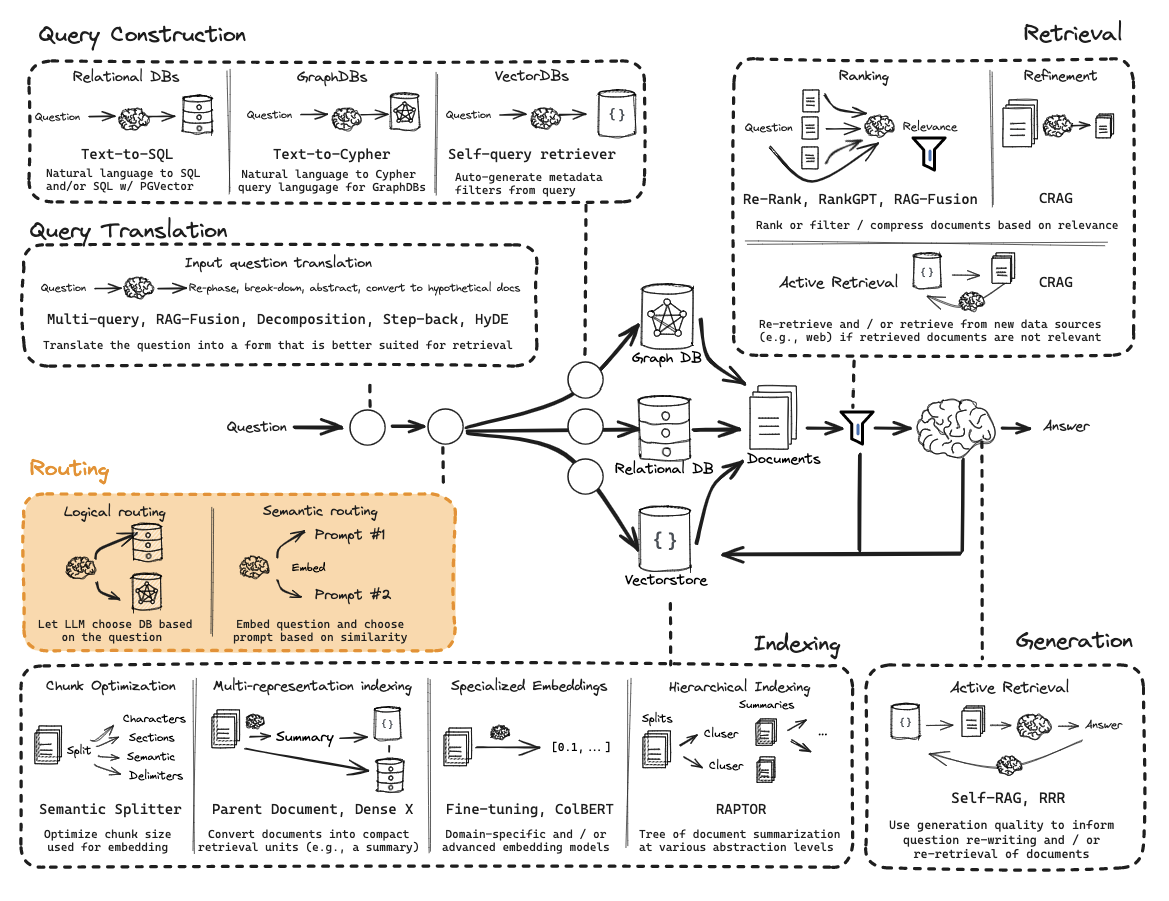

### Logical Routing

- LLM reads the question and picks from fixed routes
- `with_structured_output` forces the answer into a machine-readable enum - no text parsing
- Route -> destination mapping happens downstream (here: persona system prompts)

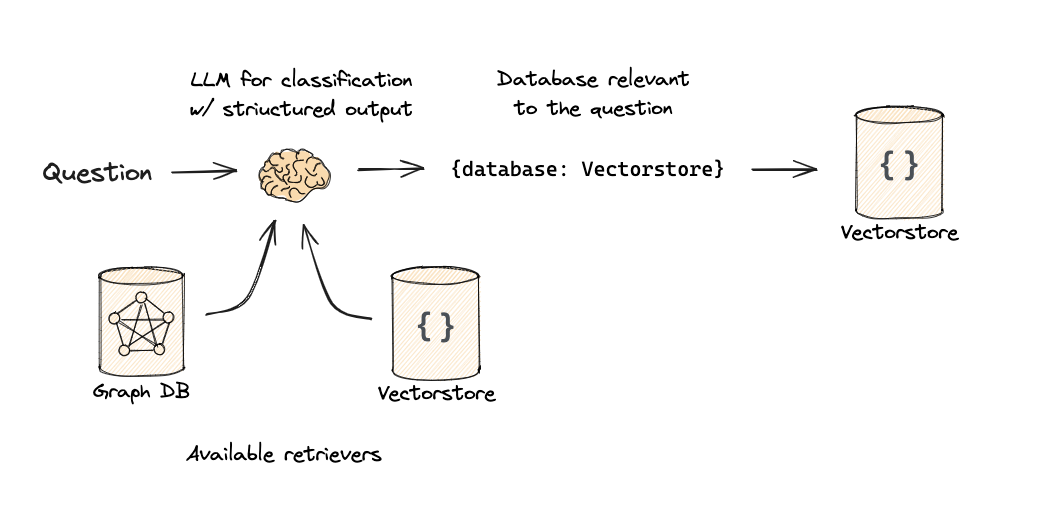

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="RAG-Routing"

`Literal[...]` makes the route set EXHAUSTIVE - the model physically cannot return anything else.
`temperature=0` for deterministic decisions. Third reuse of `with_structured_output`:
question variants (translation) -> DB filters (construction) -> route choice (here).

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field

from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

class Router(BaseModel):
    """Route a user query to the most relevant datasource."""
    data_source: Literal['python_agent', 'js_agent', 'go_agent'] = Field(
        description="Given a user question choose which datasource would be most relevant for answering their question"
    )

routuer_llm = ChatOllama(model='gemma3:4b', temperature=0)
structured_llm = routuer_llm.with_structured_output(Router)

system_prompt = """You are an expert at routing a user question to the appropriate data source.
Based on the programming language the question is referring to, route it to the relevant data source."""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{question}")
]
)

router_chain = prompt | structured_llm

question = "What is LCEL? How it is used in langchain?"
data_source = router_chain.invoke({"question":question})
data_source

In [ ]:
def choose_agent_skill(result:Router) -> dict:

    if "python" in result.data_source.lower():
        skill_prompt = "You are an expert Python developer. Answer Python questions with accurate, idiomatic, and practical solutions. Explain Python-specific behavior, syntax, standard library, runtime semantics, async, concurrency, typing, and debugging when relevant. Prefer clean, Pythonic code and explain why the solution works. Never invent APIs or behavior."
    elif "js" in result.data_source.lower():
        skill_prompt = "You are an expert JavaScript developer. Answer JavaScript questions with accurate, idiomatic, and practical solutions. Explain JavaScript-specific behavior, closures, prototypes, promises, async/await, event loop, modules, types, and runtime behavior when relevant. Distinguish browser and Node.js behavior when necessary. Prefer modern, maintainable JavaScript and never invent APIs or behavior."
    elif "go" in result.data_source.lower():
        skill_prompt = "You are an expert Go developer. Answer Go questions with accurate, idiomatic, and practical solutions. Explain Go-specific behavior, syntax, interfaces, pointers, goroutines, channels, concurrency, error handling, memory, and the standard library when relevant. Prefer simple, maintainable Go code and explain why the solution works. Never invent APIs or behavior."
    else:
        raise ValueError("No Skill loaded, Data Source not found")

    return skill_prompt

# choose_agent_skill(data_source)

The composition trick:

- `RunnablePassthrough.assign(skill=...)` ADDS a `skill` key while PRESERVING `question` -
a plain dict would drop it
- `router_chain | RunnableLambda(choose_agent_skill)` converts Router object -> persona prompt string
- `.batch()` on dicts routes all three questions independently through the same graph

This is dynamic prompting: same chain shape, different system prompt per input.

In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

agent_llm = ChatOllama(model="gemma3:4b", temperature=0.6)

python_question = "Explain Python's GIL. What does it actually prevent, how does it affect CPU-bound vs I/O-bound threads, and when would you use threading, multiprocessing, or asyncio?"
js_question = "Explain the JavaScript event loop. Given a mixture of synchronous code, Promise.then(), queueMicrotask(), setTimeout(), and setImmediate() (Node.js), what executes first and why?"
go_question = "Explain the difference between a goroutine, an OS thread, and a Go scheduler (G/M/P). How does Go execute thousands of goroutines efficiently?"

prompt = ChatPromptTemplate.from_messages([
    ("system", "{skill}"),
    ("human", "{question}")
])

router_res = RunnablePassthrough.assign(
    skill = router_chain | RunnableLambda(choose_agent_skill)
) # to preserve question passing through this chain

full_chain = router_res | prompt | agent_llm | StrOutputParser()

# for q in [python_question, js_question, go_question]:
    # print(res.invoke(q))

res = full_chain.batch([
    {"question": python_question},
    {"question": js_question},
    {"question": go_question}
])

In [ ]:
for r in res:
    print(r, end="\n")

### Semantic Routing

No LLM reasoning at all:

1. Embed candidate route templates once (offline)
2. Embed incoming query
3. `argmax(cosine_similarity)` -> pick route

Cheaper and faster than logical routing, but rigid: templates must describe the domain well,
and out-of-domain queries still get forced into SOME route (see final cells).

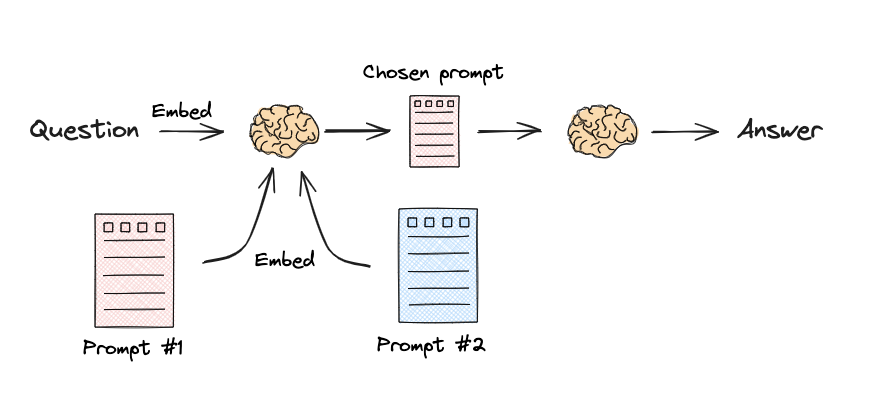

In [ ]:
from langchain_ollama import OllamaEmbeddings

physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise and easy to understand manner. \
When you don't know the answer to a question you admit that you don't know.

Here is a question:
{query}"""

math_template = """You are a very good mathematician. You are great at answering math questions. \
You are so good because you are able to break down hard problems into their component parts, \
answer the component parts, and then put them together to answer the broader question.

Here is a question:
{query}"""

embeddings = OllamaEmbeddings(model='nomic-embed-text')
prompts = [physics_template, math_template]
prompt_emd = embeddings.embed_documents(prompts)

`cosine_similarity([query_emb], prompt_emd)` -> similarity to each template;
`argmax` picks the route. The templates ARE the routes - their wording defines what lands there.

In [ ]:
from langchain_community.utils.math import cosine_similarity
from langchain_core.prompts import PromptTemplate

def choose_skill_semtantically(input:dict):
    query_embedding = embeddings.embed_query(input["query"])
    # Compute similarity
    similarity = cosine_similarity([query_embedding], prompt_emd)[0]
    print(similarity, similarity.argmax())
    most_similar = prompts[similarity.argmax()]
    # Chosen prompt 
    print("Using MATH" if most_similar == math_template else "Using PHYSICS")
    return PromptTemplate.from_template(most_similar).format(query=input["query"])


# choose_skill_semtantically("What is blackhole?")


Watch the last question ("How to bake an Cake?"): it gets forced into physics or math anyway.
Known limitations + mitigations:
- score threshold: reject when best similarity is low
- dedicated frameworks (`semantic-router`) with utterance clusters per route
- more/fewer, better-worded templates

In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

llm = ChatOllama(model='gemma3:4b')

semantic_chain = {"query" : RunnablePassthrough()} | RunnableLambda(choose_skill_semtantically) | llm | StrOutputParser()

res = semantic_chain.batch([
    "What is the speed of light and Sound?",
    "What is the the famous E=MC^2 forumla means?",
    "What is the algebra explain with an example and expression?",
    # Will answer by selecting one of them even though question is out of context so consider using similarity search with score, 
    # Dedicated Routing Frameworks (e.g., semantic-router) or Multi-Sample Utterance Clustering & Thresholds
    "How to bake an Cake?", 
])

In [ ]:
for r in res:
    print(r, end="\n")